# Clustering with Mahalanobis & Minkowski Distances

This notebook explores how different **feature-space distance metrics** affect clustering, focusing on the **Minkowski family** (L1, L2, L∞) and the **Mahalanobis distance**.

## Why Does the Distance Metric Matter in Feature Space?

Standard Euclidean distance assumes all directions are equally important and features are uncorrelated. This breaks down when:
- Features have **different scales** (income in dollars vs age in years)
- Features are **correlated** (height and weight move together)
- Clusters are **elongated or tilted** rather than round

## What We'll Cover

1. **Minkowski family (Lp):** How changing the exponent p reshapes what "closeness" means — from diamond neighborhoods (L1) to circular (L2) to square (L∞)
2. **Mahalanobis distance:** A "smart" metric that stretches and rotates space to account for feature correlations
3. **Comparison:** Side-by-side clustering of the same correlated, elliptical data

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from itertools import combinations

np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Generate Elliptical, Correlated Clusters

We deliberately create clusters that are **elongated and tilted** — the worst case for vanilla Euclidean distance. Each cluster has a different covariance structure (orientation and stretch), which means round "Euclidean neighborhoods" can't capture the true cluster shapes.

In [2]:
def make_cov(angle_deg, scale_x, scale_y):
    """Create a 2D covariance matrix with given rotation and axis scales."""
    angle = np.deg2rad(angle_deg)
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    S = np.diag([scale_x**2, scale_y**2])
    return R @ S @ R.T


def generate_elliptical_clusters(n_points=300, seed=42):
    """
    Generate 5 clusters with different elliptical shapes and orientations.
    """
    rng = np.random.default_rng(seed)
    
    configs = [
        # (center_x, center_y, rotation_deg, scale_major, scale_minor)
        (-4, 3,    30,  1.5, 0.4),    # tall, tilted right
        ( 3, 4,   -45,  1.8, 0.3),    # narrow, tilted left
        ( 0, -3,    0,  0.5, 1.5),     # vertical ellipse
        (-4, -3,   60,  1.2, 0.5),    # tilted
        ( 5, -2,  -20,  1.6, 0.4),    # elongated, slight tilt
    ]
    
    n_clusters = len(configs)
    points_per = n_points // n_clusters
    
    all_points = []
    all_labels = []
    all_covs = []
    centers = []
    
    for i, (cx, cy, angle, sx, sy) in enumerate(configs):
        n = points_per if i < n_clusters - 1 else n_points - points_per * (n_clusters - 1)
        cov = make_cov(angle, sx, sy)
        pts = rng.multivariate_normal([cx, cy], cov, size=n)
        all_points.append(pts)
        all_labels.append(np.full(n, i))
        all_covs.append(cov)
        centers.append([cx, cy])
    
    return (
        np.concatenate(all_points),
        np.concatenate(all_labels),
        np.array(centers),
        all_covs
    )


K = 5
points, true_labels, true_centers, true_covs = generate_elliptical_clusters(n_points=300)

print(f"Generated {len(points)} points in {K} clusters")
print(f"X range: [{points[:,0].min():.1f}, {points[:,0].max():.1f}]")
print(f"Y range: [{points[:,1].min():.1f}, {points[:,1].max():.1f}]")

Generated 300 points in 5 clusters
X range: [-6.7, 9.4]
Y range: [-6.4, 7.6]


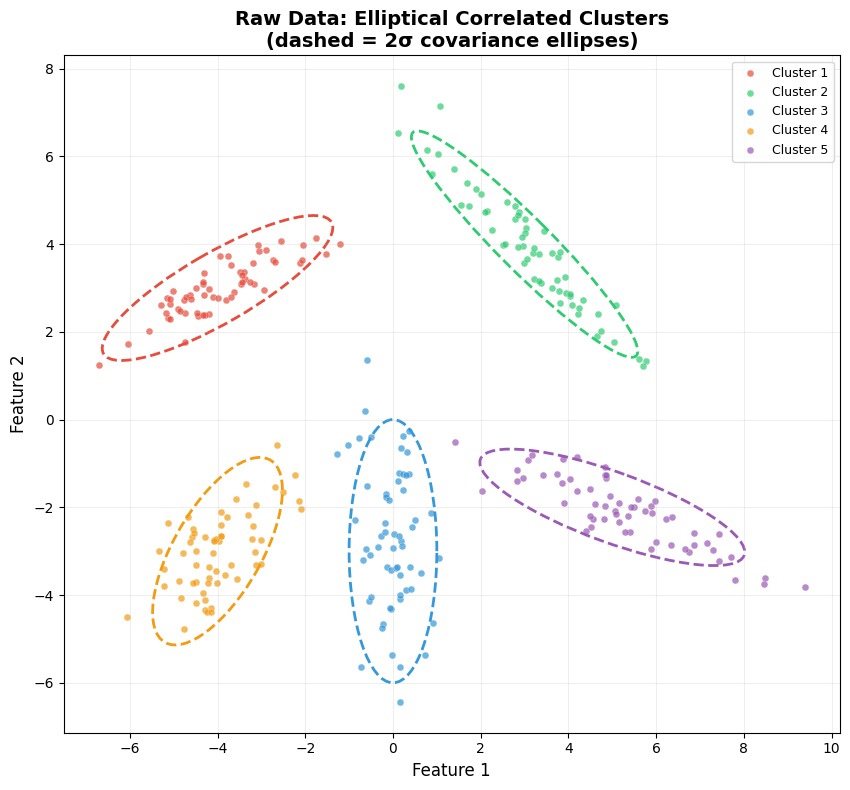

In [3]:
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

def draw_cov_ellipse(ax, center, cov, n_std=2, **kwargs):
    """Draw a covariance ellipse on an axis."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse


# Visualize the raw data with covariance ellipses
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(K):
    mask = true_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=25, alpha=0.7, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}')
    draw_cov_ellipse(ax, true_centers[i], true_covs[i], n_std=2,
                     fill=False, edgecolor=cluster_colors[i], linewidth=2, linestyle='--')

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Raw Data: Elliptical Correlated Clusters\n(dashed = 2\u03c3 covariance ellipses)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 3. Minkowski Family (Lp Distances)

The Minkowski distance generalizes Euclidean distance with a parameter $p$:

$$d_p(\mathbf{u}, \mathbf{v}) = \left(\sum_i |u_i - v_i|^p\right)^{1/p}$$

Special cases:
- **p = 1 (Manhattan / L1):** Sum of absolute differences. "Taxi cab" distance — you can only travel along grid lines. Neighborhood shape: **diamond**.
- **p = 2 (Euclidean / L2):** The familiar straight-line distance. Neighborhood shape: **circle**.
- **p → ∞ (Chebyshev / L∞):** Maximum absolute difference across any single dimension. "Chess king" distance. Neighborhood shape: **square**.

**Analogy:** Think of p as a "sharpness dial" for how you measure closeness. At p=1, you care about total effort across all dimensions equally. At p=∞, you only care about the single worst dimension.

### 3a. Unit Ball Gallery — How p Reshapes "Closeness"

The unit ball is the set of all points at distance ≤ 1 from the origin. Its shape reveals the geometry of each metric.

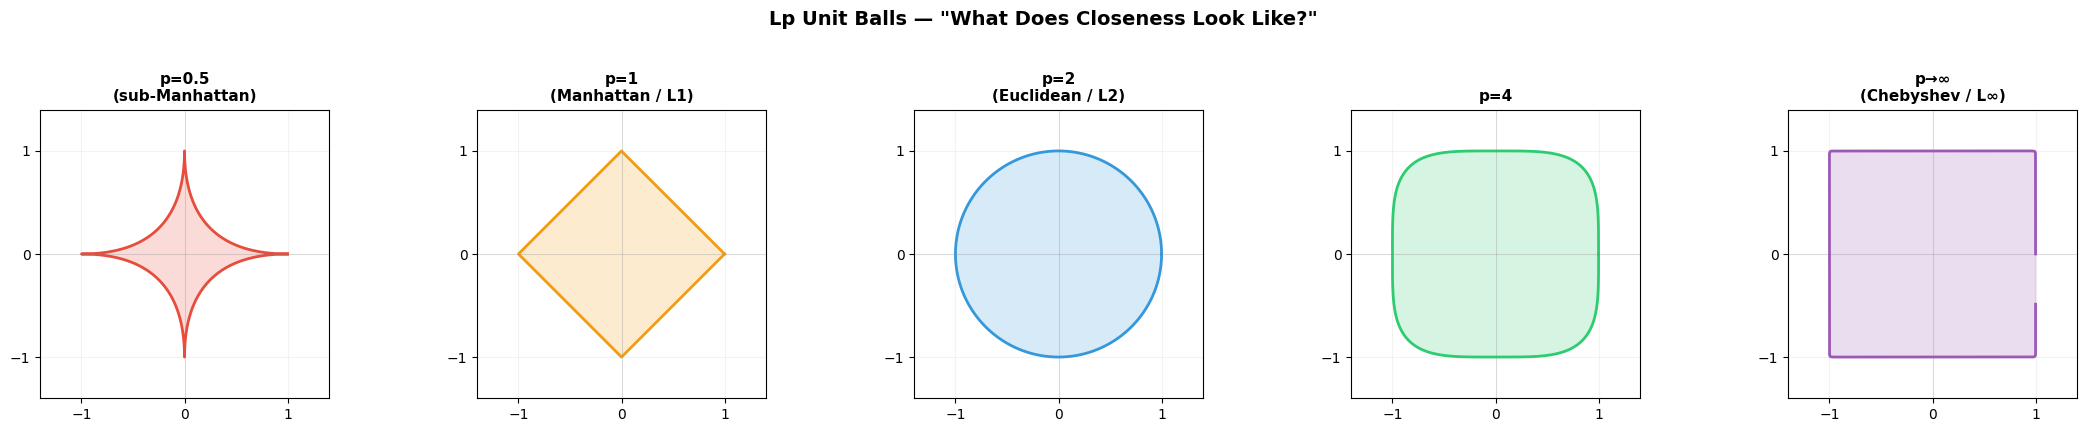

Diamond (L1) → Circle (L2) → Square (L∞)
As p increases, the unit ball inflates toward a square.
At p<1, the ball pinches inward — it becomes spiky (and technically not a proper norm).


In [4]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

p_values = [0.5, 1, 2, 4, 100]  # p=100 approximates L-infinity
p_labels = ['p=0.5\n(sub-Manhattan)', 'p=1\n(Manhattan / L1)', 'p=2\n(Euclidean / L2)',
            'p=4', 'p\u2192\u221e\n(Chebyshev / L\u221e)']
ball_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']

theta = np.linspace(0, 2*np.pi, 1000)

for ax, p, label, color in zip(axes, p_values, p_labels, ball_colors):
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    x = np.sign(cos_t) * np.abs(cos_t)**(2/p)
    y = np.sign(sin_t) * np.abs(sin_t)**(2/p)
    
    ax.fill(x, y, alpha=0.2, color=color)
    ax.plot(x, y, color=color, linewidth=2)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.3)
    ax.grid(True, alpha=0.15)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

plt.suptitle('Lp Unit Balls \u2014 "What Does Closeness Look Like?"',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Diamond (L1) \u2192 Circle (L2) \u2192 Square (L\u221e)")
print("As p increases, the unit ball inflates toward a square.")
print("At p<1, the ball pinches inward \u2014 it becomes spiky (and technically not a proper norm).")

### 3b. Minkowski Distance Implementation & K-Means

In [5]:
def minkowski_distance(u, v, p=2):
    """
    Compute Minkowski Lp distance.
    u, v: (N, D) or (D,) arrays.
    For p >= 100, uses Chebyshev (L-infinity) approximation.
    """
    diff = np.abs(u - v)
    if p >= 100:
        return np.max(diff, axis=-1)
    return np.sum(diff**p, axis=-1)**(1/p)


def minkowski_distance_matrix(points, centers, p=2):
    """Distance matrix using Minkowski Lp."""
    n = len(points)
    k = len(centers)
    D = np.zeros((n, k))
    for j in range(k):
        D[:, j] = minkowski_distance(points, centers[j], p)
    return D


def minkowski_kmeans(points, k=5, p=2, max_iter=100, tol=1e-6, seed=123):
    """
    K-means using Minkowski Lp distance.
    
    Note: The optimal centroid for Lp is NOT the arithmetic mean for p!=2.
    - L1 optimal centroid = coordinate-wise median
    - L2 optimal centroid = coordinate-wise mean
    - L-infinity optimal centroid = coordinate-wise midrange
    We use the appropriate estimator for each.
    """
    rng = np.random.default_rng(seed)
    n = len(points)
    
    init_idx = rng.choice(n, size=k, replace=False)
    centers = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist_matrix = minkowski_distance_matrix(points, centers, p)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        new_centers = np.zeros_like(centers)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centers[j] = points[rng.choice(n)]
            elif p <= 1.0 + 1e-6:  # L1: median
                new_centers[j] = np.median(members, axis=0)
            elif p >= 100:  # L-infinity: midrange
                new_centers[j] = (members.max(axis=0) + members.min(axis=0)) / 2
            else:  # General: use mean as approximation
                new_centers[j] = members.mean(axis=0)
        
        shift = np.max(np.linalg.norm(centers - new_centers, axis=1))
        centers = new_centers
        
        if shift < tol:
            break
    
    return labels, centers, history


# Run K-means with different p values
p_configs = [
    (1,   'Manhattan (L1)'),
    (2,   'Euclidean (L2)'),
    (100, 'Chebyshev (L\u221e)'),
]

minkowski_results = {}
for p_val, name in p_configs:
    lbls, ctrs, hist = minkowski_kmeans(points, k=K, p=p_val, max_iter=100)
    minkowski_results[name] = {'labels': lbls, 'centers': ctrs, 'history': hist, 'p': p_val}
    print(f"{name:20s} \u2014 converged in {len(hist)} iters, "
          f"sizes: {[np.sum(lbls == i) for i in range(K)]}")

Manhattan (L1)       — converged in 5 iters, sizes: [np.int64(56), np.int64(64), np.int64(60), np.int64(62), np.int64(58)]
Euclidean (L2)       — converged in 5 iters, sizes: [np.int64(57), np.int64(61), np.int64(61), np.int64(61), np.int64(60)]
Chebyshev (L∞)       — converged in 8 iters, sizes: [np.int64(54), np.int64(68), np.int64(59), np.int64(53), np.int64(66)]


### 3c. Minkowski Clustering — Side by Side with Voronoi Regions

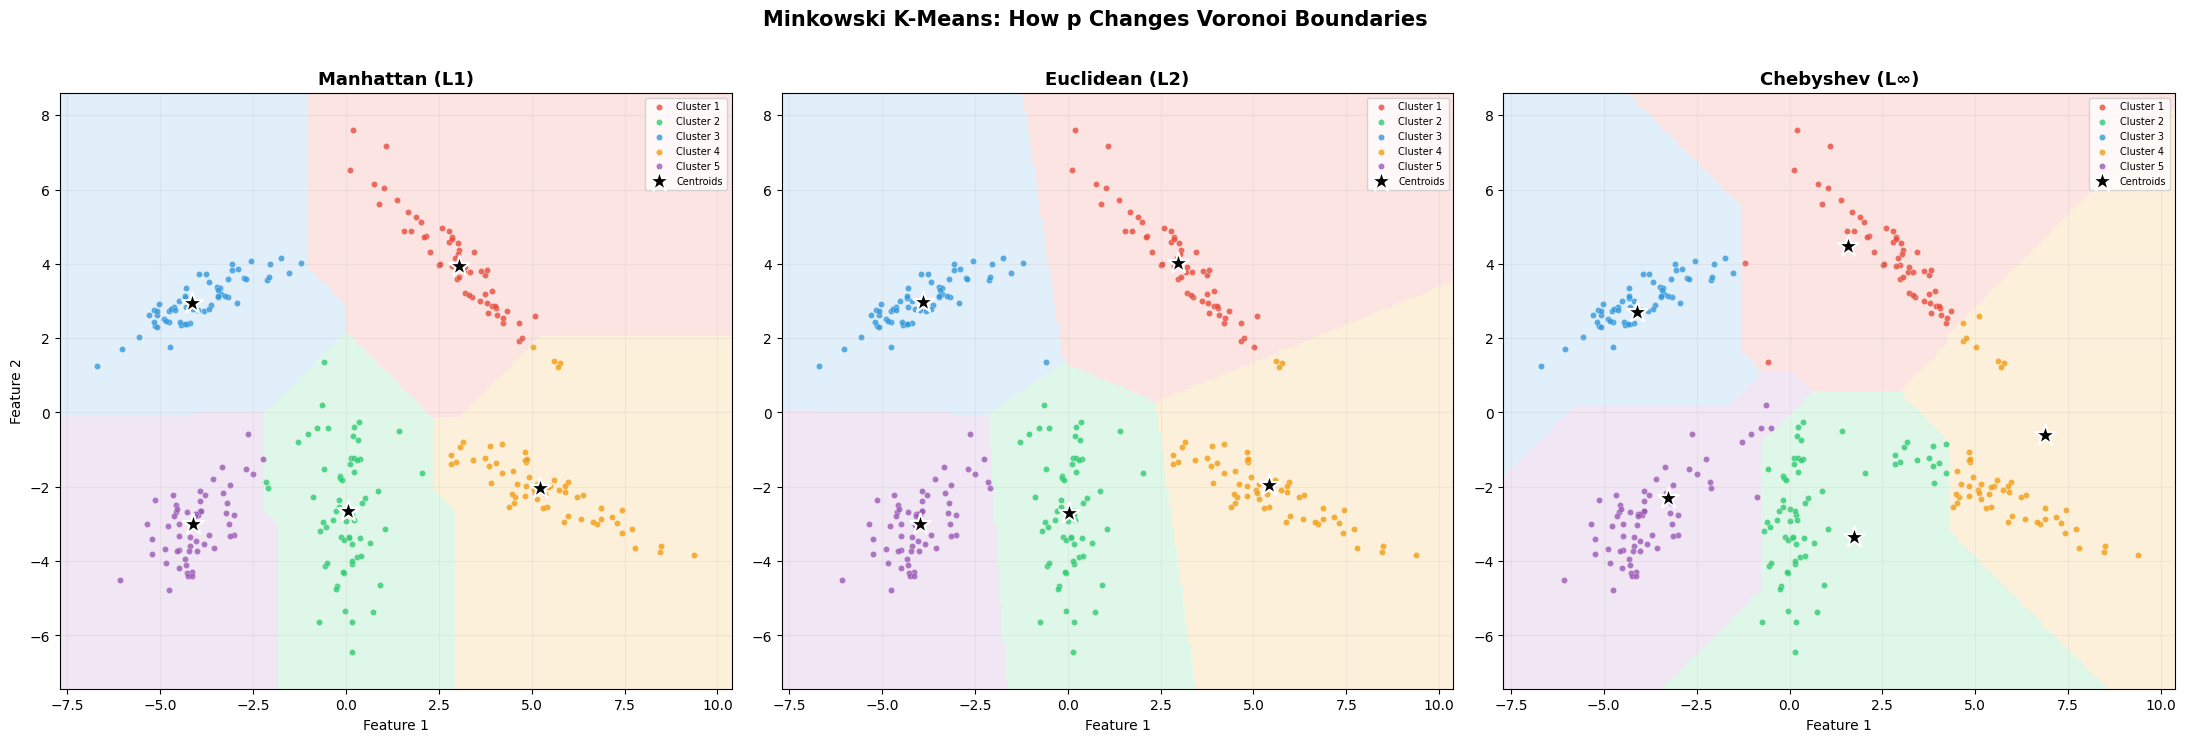

Notice the Voronoi boundary shapes:
  L1 (Manhattan): boundaries have diagonal segments
  L2 (Euclidean): boundaries are straight perpendicular bisectors
  L∞ (Chebyshev): boundaries have axis-aligned (horizontal/vertical) segments


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Background grid
grid_res = 250
x_range = (points[:, 0].min() - 1, points[:, 0].max() + 1)
y_range = (points[:, 1].min() - 1, points[:, 1].max() + 1)
gx = np.linspace(x_range[0], x_range[1], grid_res)
gy = np.linspace(y_range[0], y_range[1], grid_res)
gx_mesh, gy_mesh = np.meshgrid(gx, gy)
grid_pts = np.stack([gx_mesh.ravel(), gy_mesh.ravel()], axis=-1)

cmap_bg = mcolors.ListedColormap([mcolors.to_rgba(c, alpha=0.15) for c in cluster_colors])

for idx, (name, res) in enumerate(minkowski_results.items()):
    ax = axes[idx]
    lbls = res['labels']
    ctrs = res['centers']
    p_val = res['p']
    
    # Voronoi background
    g_d = minkowski_distance_matrix(grid_pts, ctrs, p_val)
    g_l = np.argmin(g_d, axis=1).reshape(grid_res, grid_res)
    
    ax.imshow(g_l, extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
              origin='lower', aspect='equal', cmap=cmap_bg, interpolation='nearest')
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(points[mask, 0], points[mask, 1],
                   c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
                   linewidths=0.2, label=f'Cluster {i+1}')
    
    ax.scatter(ctrs[:, 0], ctrs[:, 1], c='black', marker='*', s=250,
               edgecolors='white', linewidths=1.5, zorder=10, label='Centroids')
    
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1')
    if idx == 0:
        ax.set_ylabel('Feature 2')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.15)

plt.suptitle('Minkowski K-Means: How p Changes Voronoi Boundaries',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Notice the Voronoi boundary shapes:")
print("  L1 (Manhattan): boundaries have diagonal segments")
print("  L2 (Euclidean): boundaries are straight perpendicular bisectors")
print("  L\u221e (Chebyshev): boundaries have axis-aligned (horizontal/vertical) segments")

---
## 4. Mahalanobis Distance

The Mahalanobis distance accounts for the **shape and orientation** of the data by incorporating its covariance structure:

$$d_M(\mathbf{u}, \mathbf{v}) = \sqrt{(\mathbf{u} - \mathbf{v})^T \Sigma^{-1} (\mathbf{u} - \mathbf{v})}$$

where $\Sigma$ is the covariance matrix.

**Analogy:** Imagine you're in a city where avenues run diagonally. Euclidean distance would measure "as the crow flies," ignoring the street grid. Mahalanobis distance measures along the natural axes of the data — it stretches compressed dimensions and compresses stretched ones, then rotates to align with the principal directions.

**Effect:** After Mahalanobis transformation, elongated elliptical clusters become circular — making K-means much more effective.

### Two Variants:
1. **Global Mahalanobis:** One covariance matrix estimated from ALL data — good first approximation
2. **Per-Cluster Mahalanobis:** Each cluster gets its own covariance — essentially a simplified Gaussian Mixture Model

In [7]:
def mahalanobis_distance(u, v, cov_inv):
    """
    Compute Mahalanobis distance between u and v given inverse covariance.
    u: (N, D) or (D,), v: (D,)
    """
    diff = u - v
    if diff.ndim == 1:
        return np.sqrt(diff @ cov_inv @ diff)
    # Vectorized for N points
    return np.sqrt(np.sum((diff @ cov_inv) * diff, axis=1))


def mahalanobis_distance_matrix(points, centers, cov_inv):
    """Distance matrix using a single (global) inverse covariance."""
    n = len(points)
    k = len(centers)
    D = np.zeros((n, k))
    for j in range(k):
        D[:, j] = mahalanobis_distance(points, centers[j], cov_inv)
    return D


def mahalanobis_kmeans_global(points, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means with global Mahalanobis distance.
    Uses the full dataset's covariance to define the metric.
    """
    rng = np.random.default_rng(seed)
    n = len(points)
    
    # Compute global covariance
    global_cov = np.cov(points.T)
    global_cov_inv = np.linalg.inv(global_cov + 1e-6 * np.eye(points.shape[1]))
    
    init_idx = rng.choice(n, size=k, replace=False)
    centers = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist_matrix = mahalanobis_distance_matrix(points, centers, global_cov_inv)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        new_centers = np.zeros_like(centers)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centers[j] = points[rng.choice(n)]
            else:
                new_centers[j] = members.mean(axis=0)
        
        shift = np.max(np.linalg.norm(centers - new_centers, axis=1))
        centers = new_centers
        
        if shift < tol:
            break
    
    return labels, centers, history, global_cov, global_cov_inv


# Run global Mahalanobis K-means
mah_g_labels, mah_g_centers, mah_g_history, global_cov, global_cov_inv = \
    mahalanobis_kmeans_global(points, k=K, max_iter=100)

print(f"Global Mahalanobis K-Means \u2014 converged in {len(mah_g_history)} iters")
print(f"Cluster sizes: {[np.sum(mah_g_labels == i) for i in range(K)]}")
print(f"\nGlobal covariance matrix:")
print(f"  [[{global_cov[0,0]:.2f}, {global_cov[0,1]:.2f}],")
print(f"   [{global_cov[1,0]:.2f}, {global_cov[1,1]:.2f}]]")

Global Mahalanobis K-Means — converged in 4 iters
Cluster sizes: [np.int64(57), np.int64(61), np.int64(61), np.int64(61), np.int64(60)]

Global covariance matrix:
  [[15.09, -0.11],
   [-0.11, 10.22]]


In [8]:
def mahalanobis_kmeans_percluster(points, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means with per-cluster Mahalanobis distance.
    Each cluster estimates its own covariance \u2014 adapts to local shape.
    """
    rng = np.random.default_rng(seed)
    n, d = points.shape
    
    init_idx = rng.choice(n, size=k, replace=False)
    centers = points[init_idx].copy()
    
    # Initialize per-cluster covariances as identity
    cov_invs = [np.eye(d) for _ in range(k)]
    covs = [np.eye(d) for _ in range(k)]
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # Assignment: each point uses the covariance of each candidate cluster
        dist_matrix = np.zeros((n, k))
        for j in range(k):
            dist_matrix[:, j] = mahalanobis_distance(points, centers[j], cov_invs[j])
        
        labels = np.argmin(dist_matrix, axis=1)
        total_dist = sum(dist_matrix[i, labels[i]] for i in range(n))
        history.append(total_dist)
        
        # Update centers and per-cluster covariances
        new_centers = np.zeros_like(centers)
        for j in range(k):
            members = points[labels == j]
            if len(members) < d + 1:
                new_centers[j] = centers[j]
            else:
                new_centers[j] = members.mean(axis=0)
                c = np.cov(members.T)
                c += 1e-4 * np.eye(d)  # regularization
                covs[j] = c
                cov_invs[j] = np.linalg.inv(c)
        
        shift = np.max(np.linalg.norm(centers - new_centers, axis=1))
        centers = new_centers
        
        if shift < tol:
            break
    
    return labels, centers, history, covs, cov_invs


# Run per-cluster Mahalanobis K-means
mah_pc_labels, mah_pc_centers, mah_pc_history, pc_covs, pc_cov_invs = \
    mahalanobis_kmeans_percluster(points, k=K, max_iter=100)

print(f"Per-Cluster Mahalanobis K-Means \u2014 converged in {len(mah_pc_history)} iters")
print(f"Cluster sizes: {[np.sum(mah_pc_labels == i) for i in range(K)]}")

Per-Cluster Mahalanobis K-Means — converged in 10 iters
Cluster sizes: [np.int64(59), np.int64(60), np.int64(1), np.int64(120), np.int64(60)]


### 4a. Mahalanobis Clustering — Visualizing the Covariance Ellipses

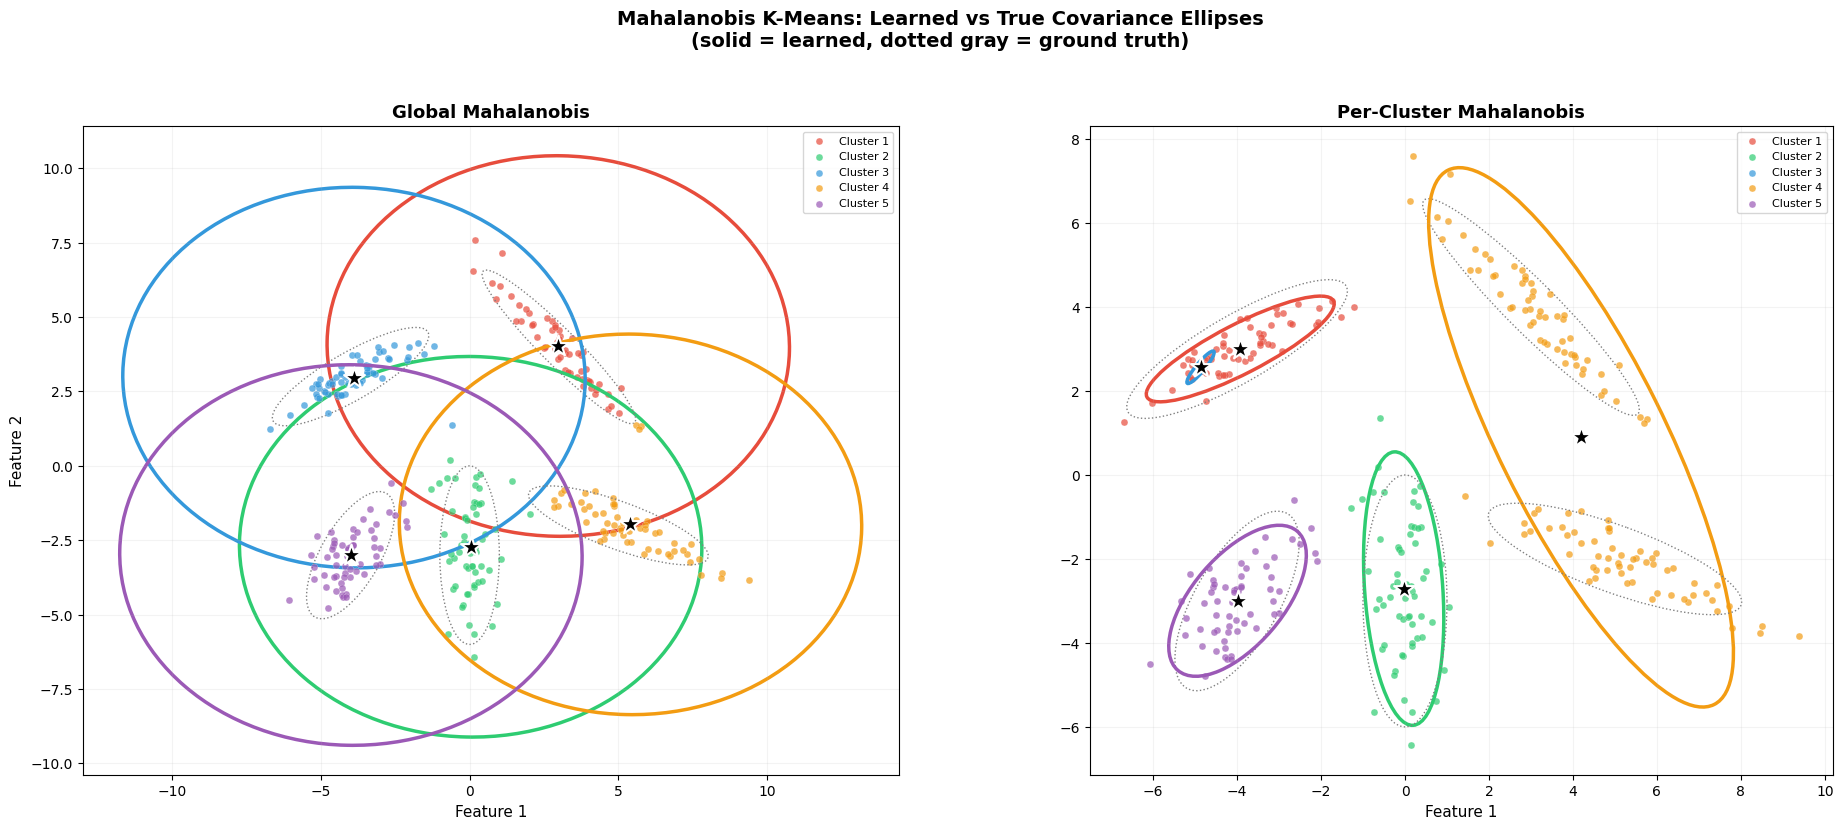

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mah_configs = [
    ('Global Mahalanobis', mah_g_labels, mah_g_centers, [global_cov]*K),
    ('Per-Cluster Mahalanobis', mah_pc_labels, mah_pc_centers, pc_covs),
]

for idx, (title, lbls, ctrs, covs_list) in enumerate(mah_configs):
    ax = axes[idx]
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(points[mask, 0], points[mask, 1],
                   c=cluster_colors[i], s=25, alpha=0.7, edgecolors='white',
                   linewidths=0.2, label=f'Cluster {i+1}')
        
        # Draw covariance ellipse used by this method
        draw_cov_ellipse(ax, ctrs[i], covs_list[i], n_std=2,
                         fill=False, edgecolor=cluster_colors[i], linewidth=2.5, linestyle='-')
        # Also draw the true covariance for comparison
        draw_cov_ellipse(ax, true_centers[i], true_covs[i], n_std=2,
                         fill=False, edgecolor='gray', linewidth=1, linestyle=':')
    
    ax.scatter(ctrs[:, 0], ctrs[:, 1], c='black', marker='*', s=250,
               edgecolors='white', linewidths=1.5, zorder=10)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Feature 2', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)

plt.suptitle('Mahalanobis K-Means: Learned vs True Covariance Ellipses\n'
             '(solid = learned, dotted gray = ground truth)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4b. What Mahalanobis "Sees" — The Whitened Space

Mahalanobis distance is equivalent to Euclidean distance in a **whitened** (decorrelated + normalized) space. Let's visualize what the data looks like after this transformation.

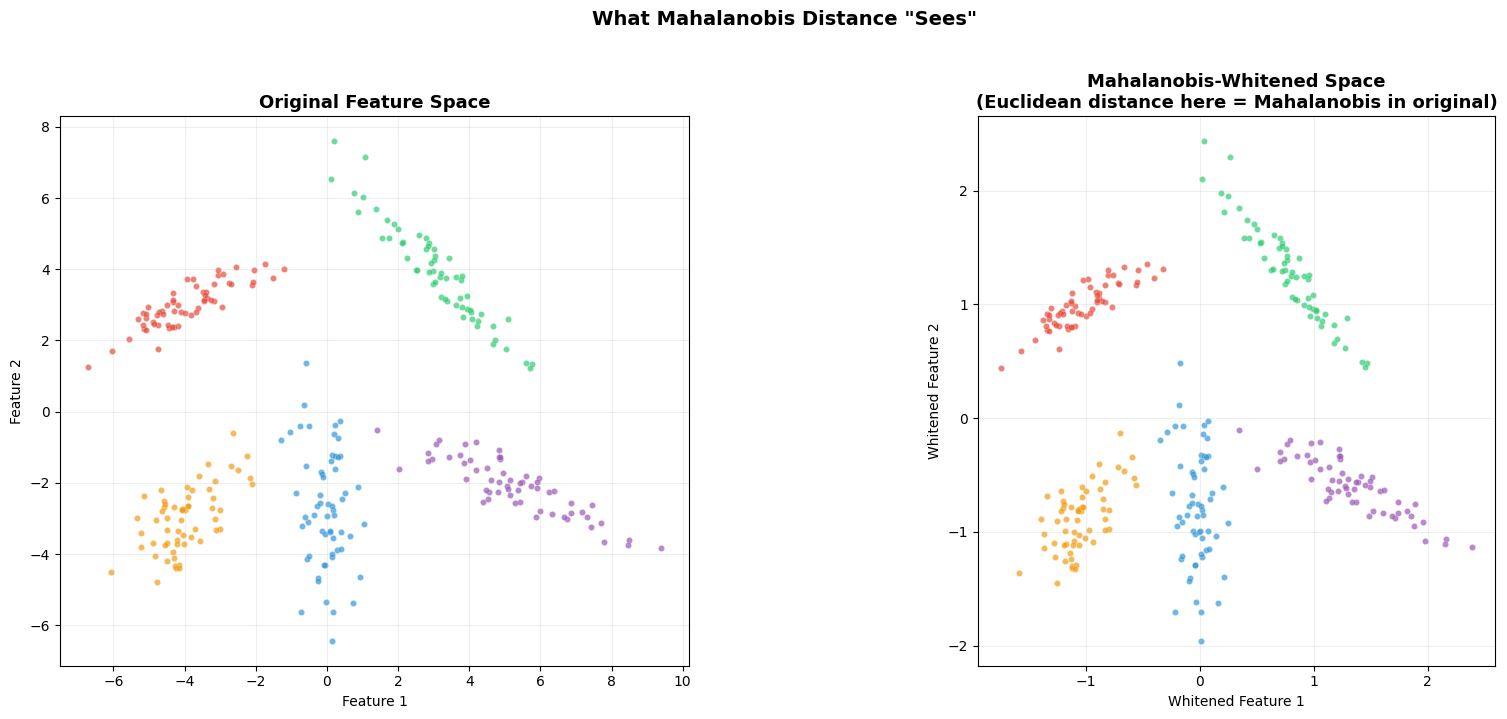

In the whitened space, the global data scatter becomes circular.
Euclidean distance in this transformed space = Mahalanobis distance in the original.


In [10]:
# Whiten the data using global covariance
eigenvalues, eigenvectors = np.linalg.eigh(global_cov)
whitening_matrix = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T
points_whitened = (points - points.mean(axis=0)) @ whitening_matrix.T

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Original space
ax = axes[0]
for i in range(K):
    mask = true_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=20, alpha=0.7, edgecolors='white', linewidths=0.2)
ax.set_title('Original Feature Space', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# Whitened space
ax = axes[1]
for i in range(K):
    mask = true_labels == i
    ax.scatter(points_whitened[mask, 0], points_whitened[mask, 1],
               c=cluster_colors[i], s=20, alpha=0.7, edgecolors='white', linewidths=0.2)
ax.set_title('Mahalanobis-Whitened Space\n(Euclidean distance here = Mahalanobis in original)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Whitened Feature 1'); ax.set_ylabel('Whitened Feature 2')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

plt.suptitle('What Mahalanobis Distance "Sees"',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("In the whitened space, the global data scatter becomes circular.")
print("Euclidean distance in this transformed space = Mahalanobis distance in the original.")

---
## 5. Full Comparison Dashboard

### 5a. All Five Methods Side by Side

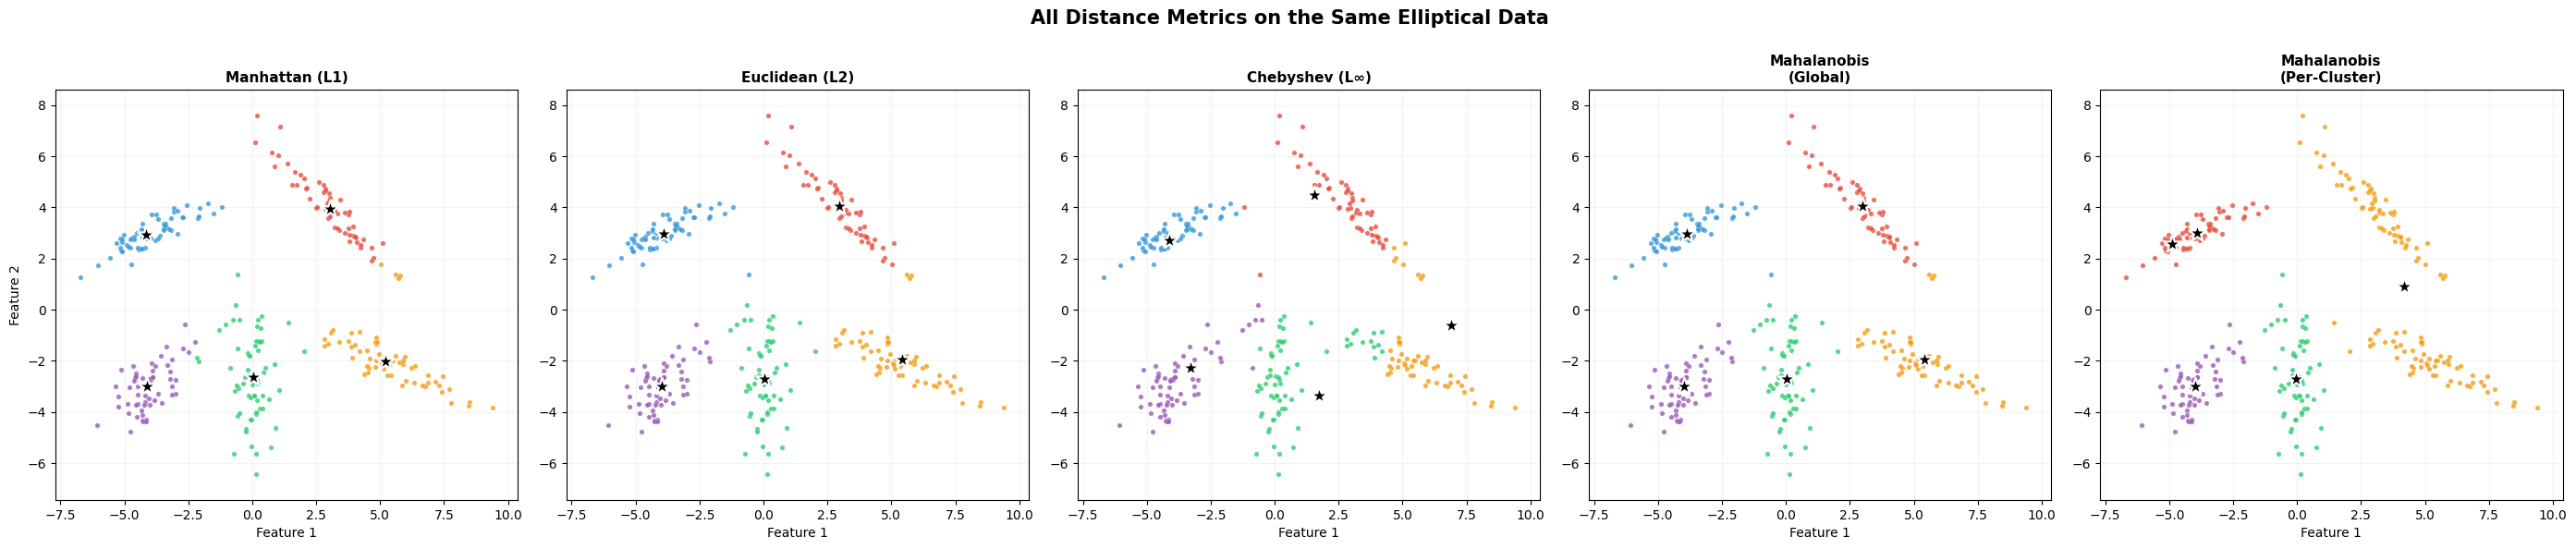

In [11]:
all_methods = {
    'Manhattan (L1)': minkowski_results['Manhattan (L1)'],
    'Euclidean (L2)': minkowski_results['Euclidean (L2)'],
    'Chebyshev (L\u221e)': minkowski_results['Chebyshev (L\u221e)'],
    'Mahalanobis\n(Global)': {'labels': mah_g_labels, 'centers': mah_g_centers},
    'Mahalanobis\n(Per-Cluster)': {'labels': mah_pc_labels, 'centers': mah_pc_centers},
}

fig, axes = plt.subplots(1, 5, figsize=(28, 5.5))

for idx, (name, res) in enumerate(all_methods.items()):
    ax = axes[idx]
    lbls = res['labels']
    ctrs = res['centers']
    
    for i in range(K):
        mask = lbls == i
        ax.scatter(points[mask, 0], points[mask, 1],
                   c=cluster_colors[i], s=15, alpha=0.8, edgecolors='white', linewidths=0.2)
    
    ax.scatter(ctrs[:, 0], ctrs[:, 1], c='black', marker='*', s=200,
               edgecolors='white', linewidths=1.5, zorder=10)
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    if idx == 0:
        ax.set_ylabel('Feature 2')
    ax.set_xlabel('Feature 1')

plt.suptitle('All Distance Metrics on the Same Elliptical Data',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 5b. Pairwise Agreement Matrix

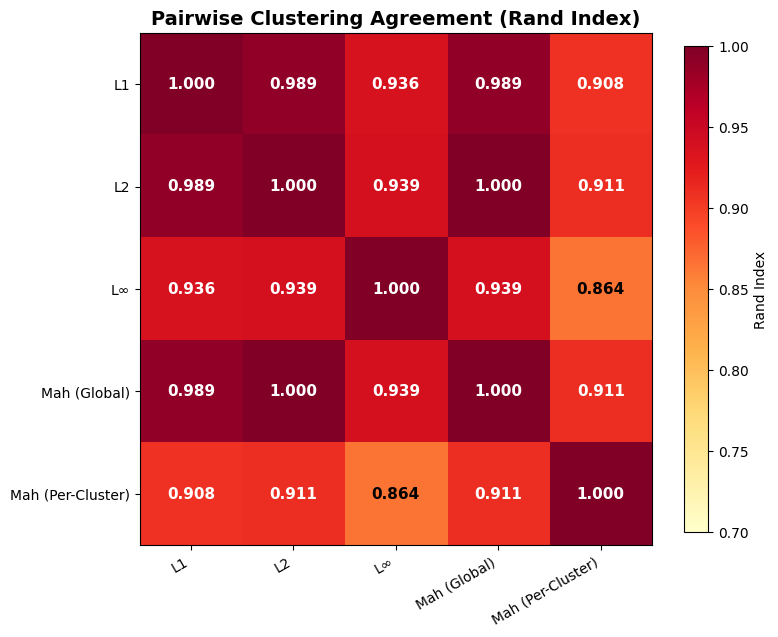

Interpretation:
  1.000 = identical clusterings (after accounting for label permutation)
  Lower values = the two metrics disagree on how to group points


In [12]:
def cluster_agreement(labels_a, labels_b):
    """Rand Index: fraction of pairs agreeing on same/different cluster."""
    n = len(labels_a)
    agree = 0
    total = 0
    for i, j in combinations(range(n), 2):
        same_a = labels_a[i] == labels_a[j]
        same_b = labels_b[i] == labels_b[j]
        if same_a == same_b:
            agree += 1
        total += 1
    return agree / total


method_names = ['L1', 'L2', 'L\u221e', 'Mah (Global)', 'Mah (Per-Cluster)']
method_labels = [
    minkowski_results['Manhattan (L1)']['labels'],
    minkowski_results['Euclidean (L2)']['labels'],
    minkowski_results['Chebyshev (L\u221e)']['labels'],
    mah_g_labels,
    mah_pc_labels,
]

n_methods = len(method_names)
agreement_matrix = np.eye(n_methods)

for i in range(n_methods):
    for j in range(i+1, n_methods):
        ri = cluster_agreement(method_labels[i], method_labels[j])
        agreement_matrix[i, j] = ri
        agreement_matrix[j, i] = ri

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(agreement_matrix, cmap='YlOrRd', vmin=0.7, vmax=1.0)

ax.set_xticks(range(n_methods))
ax.set_yticks(range(n_methods))
ax.set_xticklabels(method_names, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(method_names, fontsize=10)

# Annotate cells
for i in range(n_methods):
    for j in range(n_methods):
        val = agreement_matrix[i, j]
        color = 'white' if val > 0.9 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, label='Rand Index', shrink=0.8)
ax.set_title('Pairwise Clustering Agreement (Rand Index)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  1.000 = identical clusterings (after accounting for label permutation)")
print("  Lower values = the two metrics disagree on how to group points")

### 5c. Convergence Comparison

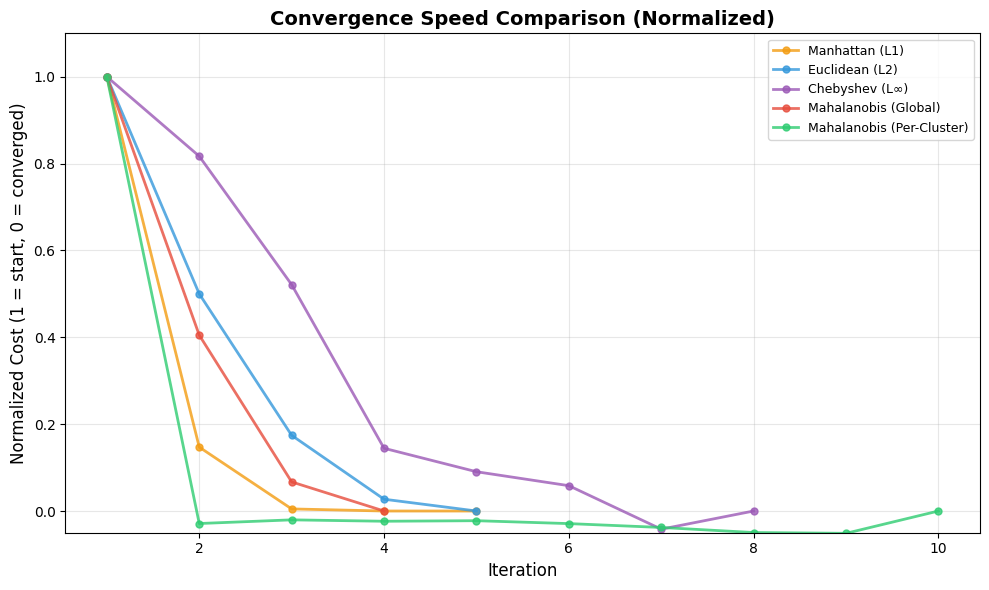

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

conv_configs = [
    ('Manhattan (L1)', minkowski_results['Manhattan (L1)']['history'], '#f39c12'),
    ('Euclidean (L2)', minkowski_results['Euclidean (L2)']['history'], '#3498db'),
    ('Chebyshev (L\u221e)', minkowski_results['Chebyshev (L\u221e)']['history'], '#9b59b6'),
    ('Mahalanobis (Global)', mah_g_history, '#e74c3c'),
    ('Mahalanobis (Per-Cluster)', mah_pc_history, '#2ecc71'),
]

for name, hist, color in conv_configs:
    # Normalize to [0, 1] range for fair comparison (different scales)
    hist_norm = np.array(hist)
    hist_norm = (hist_norm - hist_norm[-1]) / (hist_norm[0] - hist_norm[-1] + 1e-10)
    ax.plot(range(1, len(hist)+1), hist_norm, 'o-', color=color,
            markersize=5, linewidth=2, label=name, alpha=0.8)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Normalized Cost (1 = start, 0 = converged)', fontsize=12)
ax.set_title('Convergence Speed Comparison (Normalized)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### 5d. Accuracy Against Ground Truth

Agreement with Ground Truth (Rand Index)
  L1                      →  0.9792  (97.9%)
  L2                      →  0.9844  (98.4%)
  L∞                      →  0.9298  (93.0%)
  Mah (Global)            →  0.9844  (98.4%)
  Mah (Per-Cluster)       →  0.9184  (91.8%)

Best method for this data: L2 (98.4%)


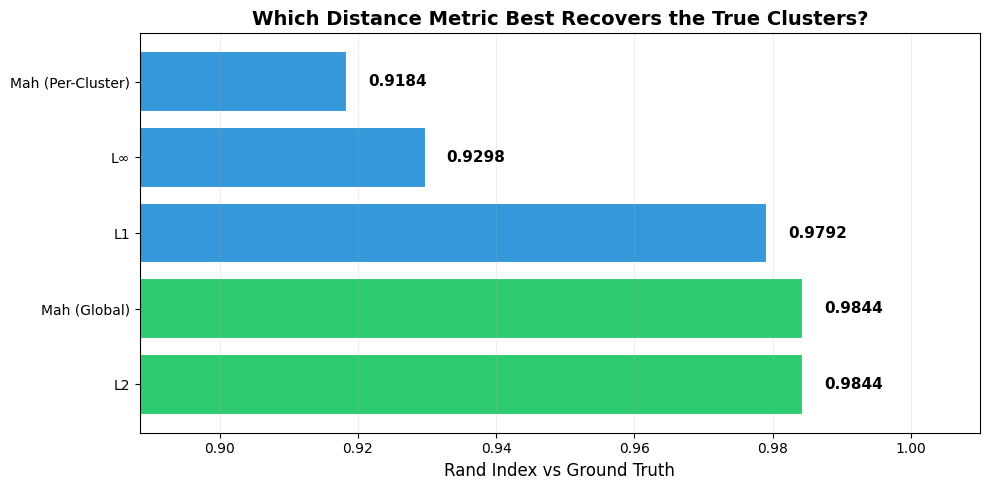

In [14]:
print("Agreement with Ground Truth (Rand Index)")
print("=" * 55)

gt_scores = []
for name, lbls in zip(method_names, method_labels):
    ri = cluster_agreement(true_labels, lbls)
    gt_scores.append((name, ri))
    print(f"  {name:22s}  \u2192  {ri:.4f}  ({ri*100:.1f}%)")

# Sort by score
gt_scores.sort(key=lambda x: x[1], reverse=True)
print(f"\nBest method for this data: {gt_scores[0][0]} ({gt_scores[0][1]*100:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names_sorted = [x[0] for x in gt_scores]
scores_sorted = [x[1] for x in gt_scores]
bar_colors = ['#2ecc71' if s == max(scores_sorted) else '#3498db' for s in scores_sorted]

bars = ax.barh(names_sorted, scores_sorted, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Rand Index vs Ground Truth', fontsize=12)
ax.set_title('Which Distance Metric Best Recovers the True Clusters?',
             fontsize=14, fontweight='bold')
ax.set_xlim(min(scores_sorted) - 0.03, 1.01)

for bar, score in zip(bars, scores_sorted):
    ax.text(score + 0.003, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')

ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# K-sweep using Euclidean (L2) distance — the natural choice for TWCSS.
# minkowski_distance and minkowski_kmeans are already defined above.

# Build full N×N Euclidean (L2) pairwise distance matrix
n_pts = len(points)
print("Building pairwise Euclidean distance matrix...")
D_full = minkowski_distance_matrix(points, points, p=2)  # N×N

# TWCSS baseline: one cluster, centred on the arithmetic mean
overall_center = points.mean(axis=0)
TWCSS_1 = float(np.sum(minkowski_distance(points, overall_center, p=2) ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, cents_k, _ = minkowski_kmeans(points, k=k, p=2, max_iter=100)
    dists_k = minkowski_distance(points, cents_k[lbls_k], p=2)
    twcss_k = float(np.sum(dists_k ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_full, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 6. Summary

| Metric | Formula | Neighborhood Shape | Centroid | Best For |
|--------|---------|-------------------|----------|----------|
| **Manhattan (L1)** | $\sum |u_i - v_i|$ | Diamond | Coordinate-wise median | Sparse, high-dim data; robust to outliers |
| **Euclidean (L2)** | $\sqrt{\sum (u_i - v_i)^2}$ | Circle | Arithmetic mean | General-purpose; isotropic clusters |
| **Chebyshev (L\u221e)** | $\max |u_i - v_i|$ | Square | Coordinate-wise midrange | When worst-case dimension matters |
| **Mahalanobis (Global)** | $(\Delta)^T \Sigma^{-1} (\Delta)$ | Ellipse (one shape) | Mean | Correlated features, single shape |
| **Mahalanobis (Per-Cluster)** | Per-cluster $\Sigma_j^{-1}$ | Ellipse (per cluster) | Mean + covariance update | Clusters with different shapes/orientations |

### Key Takeaways

1. **Minkowski p controls neighborhood geometry.** L1 gives diamond-shaped regions (good for sparse/axis-aligned data), L2 gives circles (the default), L\u221e gives squares (when you care about the worst-case dimension).

2. **Mahalanobis "de-correlates" the data.** It's equivalent to running Euclidean K-means in a whitened (decorrelated + normalized) space. This makes it much better for tilted, elongated clusters.

3. **Per-cluster Mahalanobis is a simplified Gaussian Mixture Model.** Each cluster learns its own shape \u2014 this bridges the gap between K-means and full probabilistic clustering.

4. **No single metric wins everywhere.** The best choice depends on your data's structure. The comparison framework in this notebook helps you evaluate which metric fits your specific dataset.